In [1]:
import scanpy as sc

adata = sc.read_h5ad(r"C:\Users\USER\Desktop\資訊所實習\計畫\challenge_nasal_cellxgene_230223.h5ad")

In [14]:
adata

AnnData object with n_obs × n_vars = 234182 × 33559
    obs: 'patient_id', 'time_point', 'covid_status', 'sex', 'cell_state', 'cell_type', 'cell_compartment', 'cell_state_woIFN', 'sequencing_library', 'Institute', 'ObjectCreateDate'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_umap_rna_30pcs_6000hvgs'

In [15]:
summary = {
    "Number of cells": adata.n_obs,
    "Number of genes": adata.n_vars,
    "obs columns": list(adata.obs.columns),
    "var columns": list(adata.var.columns),
    "embeddings": list(adata.obsm.keys())
}

for k, v in summary.items():
    print(f"\n{k}:")
    print(v)


Number of cells:
234182

Number of genes:
33559

obs columns:
['patient_id', 'time_point', 'covid_status', 'sex', 'cell_state', 'cell_type', 'cell_compartment', 'cell_state_woIFN', 'sequencing_library', 'Institute', 'ObjectCreateDate']

var columns:
['vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable']

embeddings:
['X_umap_rna_30pcs_6000hvgs']


In [13]:
adata.var

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable
MIR1302-2HG,0.000435,0.000434,0.000489,0.887800,False
FAM138A,0.000094,0.000094,0.000102,0.921153,False
OR4F5,0.000004,0.000004,0.000004,0.946429,False
AL627309.1,0.001506,0.001504,0.001791,0.839535,False
AL627309.3,0.000100,0.000099,0.000109,0.909185,False
...,...,...,...,...,...
VIRAL-Mumps-rubulavirus,0.000000,0.000000,0.000000,0.000000,False
VIRAL-Rubella,0.000000,0.000000,0.000000,0.000000,False
VIRAL-Varicella-Zoster-Virus-(VZV-Human-alphaherpesvirus-3),0.000000,0.000000,0.000000,0.000000,False
VIRAL-Cytomegalovieus-(CMV),0.000000,0.000000,0.000000,0.000000,False


In [16]:
print(adata.obs["cell_type"].value_counts())

cell_type
Ciliated         166318
T CD8             25153
Goblet            10586
Secretory          6442
Basal              5219
Macrophage         3948
T CD4              2971
Ionocyte           2586
Club               1890
Deutorosomal       1307
NK                 1082
T MAI               962
Monocyte            868
cDC2                851
Langerhans          707
cDC Activated       590
B                   466
pDC                 443
T G/D               346
T Reg               302
Hillock             280
Squamous            279
Ductal              275
cDC1                118
AS-DC                95
Mast                 64
Melanocyte           34
Name: count, dtype: int64


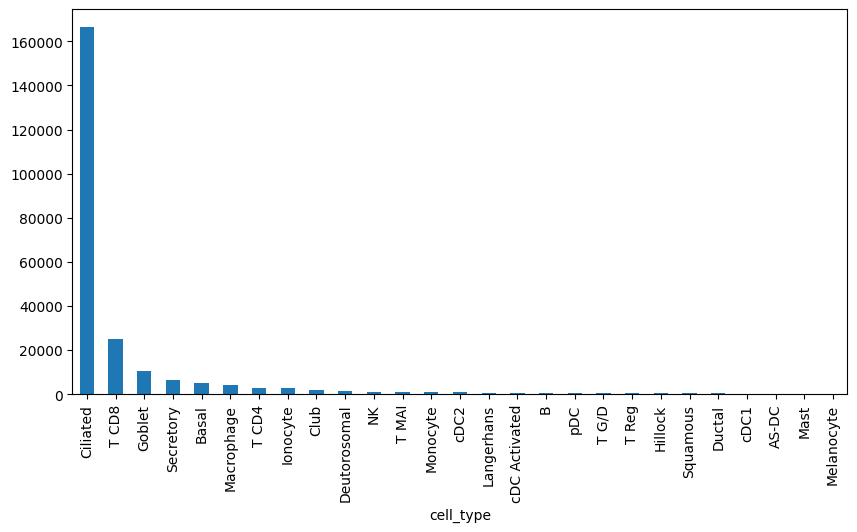

In [5]:
import matplotlib.pyplot as plt

adata.obs["cell_type"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.xticks(rotation=90)
plt.show()

In [7]:
print(adata.obs["cell_state"].value_counts())

cell_state
Ciliated                 111572
Ciliated APR / MHCII+     34458
T CD8 Resident Memory     20467
Ciliated IFN stim         19347
Goblet                     7112
                          ...  
B IgD                        12
NK Cycling                   12
B IFN stim IgG               10
B IFN stim IgA                8
B IFN stim IgD                1
Name: count, Length: 76, dtype: int64


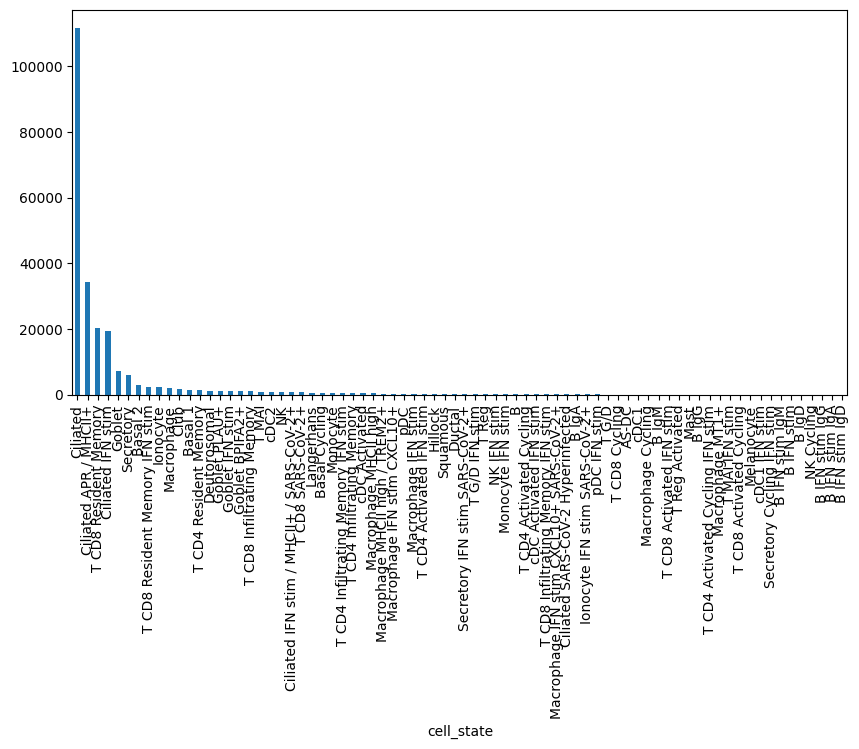

In [22]:
adata.obs["cell_state"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.xticks(rotation=90)
plt.show()

In [17]:
import numpy as np

# 每個 cell type 保留數量
n_per_type = 100

selected_cells = (
    adata.obs
    .groupby("cell_type", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(len(x), n_per_type),
            random_state=123
        )
    )
    .index
)

adata_sub = adata[selected_cells].copy()

print(adata_sub)

C:\Users\USER\AppData\Local\Temp\ipykernel_22360\3617280068.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("cell_type", group_keys=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_22360\3617280068.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


AnnData object with n_obs × n_vars = 2593 × 33559
    obs: 'patient_id', 'time_point', 'covid_status', 'sex', 'cell_state', 'cell_type', 'cell_compartment', 'cell_state_woIFN', 'sequencing_library', 'Institute', 'ObjectCreateDate'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_umap_rna_30pcs_6000hvgs'


In [18]:
adata_hvg = adata_sub[
    :,
    adata_sub.var["vst.variable"]
].copy()

In [19]:
print(adata_hvg)

AnnData object with n_obs × n_vars = 2593 × 8000
    obs: 'patient_id', 'time_point', 'covid_status', 'sex', 'cell_state', 'cell_type', 'cell_compartment', 'cell_state_woIFN', 'sequencing_library', 'Institute', 'ObjectCreateDate'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_umap_rna_30pcs_6000hvgs'


In [20]:
summary_sub = {
    "Number of cells": adata_hvg.n_obs,
    "Number of genes": adata_hvg.n_vars,
    "obs columns": list(adata_hvg.obs.columns),
    "var columns": list(adata_hvg.var.columns),
    "embeddings": list(adata_hvg.obsm.keys())
}

for k, v in summary_sub.items():
    print(f"\n{k}:")
    print(v)


Number of cells:
2593

Number of genes:
8000

obs columns:
['patient_id', 'time_point', 'covid_status', 'sex', 'cell_state', 'cell_type', 'cell_compartment', 'cell_state_woIFN', 'sequencing_library', 'Institute', 'ObjectCreateDate']

var columns:
['vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable']

embeddings:
['X_umap_rna_30pcs_6000hvgs']


In [21]:
import pandas as pd

expr_df = pd.DataFrame(
    adata_hvg.X.toarray(),
    index=adata_hvg.obs_names,
    columns=adata_hvg.var_names
)

In [22]:
cell_type_df = adata_hvg.obs[["cell_type"]]

final_df = pd.concat(
    [
        cell_type_df,
        expr_df
    ],
    axis=1
)

final_df.head()

,cell_type,AL645608.5,SAMD11,AL645608.8,HES4,ISG15,TNFRSF18,TNFRSF4,VWA1,GNB1,...,MT-ND6,AC141272.1,AC136352.2,AC011043.2,AC007325.4,AC004556.1,AC233755.2,AC233755.1,VIRAL-EBV1-(Human-gammaherpesvirus-4),VIRAL-SARS-CoV2
COV19_CH11931834_CGATGTAGTGACTCAT,AS-DC,0.0,0.0,0.0,0.000000,1.215737,0.0,0.0,0.0,0.581306,...,0.0,0.0,0.0,0.0,0.000000,0.578337,0.0,0.0,0.0,0.0
COV19_CH11931816_GTACGTACAAGCCTAT,AS-DC,0.0,0.0,0.0,1.233684,0.473900,0.0,0.0,0.0,0.472906,...,0.0,0.0,0.0,0.0,0.470634,0.469671,0.0,0.0,0.0,0.0
COV19_CH11283371_GCATACAGTAAACGCG,AS-DC,0.0,0.0,0.0,3.616444,3.048887,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
COV19_CH11283391_GTGCGGTGTTAAGGGC,AS-DC,0.0,0.0,0.0,0.000000,1.991147,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,1.593459,0.0,0.0,0.0,0.0
COV19_CH11931841_GTCGTAAGTAGAAGGA,AS-DC,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,1.074006,...,0.0,0.0,0.0,0.0,0.000000,0.459479,0.0,0.0,0.0,0.0


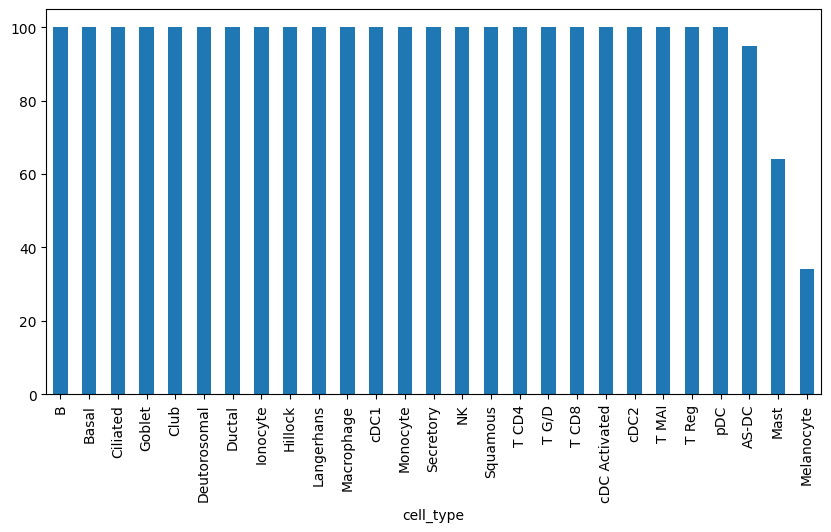

In [36]:
final_df["cell_type"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.xticks(rotation=90)
plt.show()

In [23]:
final_df = final_df.reset_index()

final_df = final_df.rename(
    columns={"index": "cell_id"}
)

In [32]:
print(final_df.iloc[:, [0,1] + list(range(200,203))].head())

                             cell_id cell_type  CDC20    ELOVL1  AL451062.1
0  COV19_CH11931834_CGATGTAGTGACTCAT     AS-DC    0.0  0.585226         0.0
1  COV19_CH11931816_GTACGTACAAGCCTAT     AS-DC    0.0  0.000000         0.0
2  COV19_CH11283371_GCATACAGTAAACGCG     AS-DC    0.0  0.749799         0.0
3  COV19_CH11283391_GTGCGGTGTTAAGGGC     AS-DC    0.0  0.000000         0.0
4  COV19_CH11931841_GTCGTAAGTAGAAGGA     AS-DC    0.0  0.000000         0.0


In [ ]:
#final_df.to_csv(
#    r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\nasal_scRNA_HVG_100cells.csv",
#    index=False
#)